### Purpose

The purpose of this notebook is to quantify spatial relationships between oil and gas wells and saltwater injection wells (SWIW) across the study area.

### Load Libraries

In [1]:
import pandas as pd
import numpy as np
from geopy.distance import geodesic
import geopandas as gpd
from shapely.geometry import Point
from tqdm import tqdm

### Load Data

In [14]:
well_info = pd.read_csv('../data/final/well_information_final.csv')
permits = pd.read_csv('../data/final/permit_plug_list_final.csv')

### Create GeoDataFrames for each dataset

In [ ]:
well_info = well_info.dropna(subset=['WELL LATITUDE', 'WELL LONGITUDE'])
permits = permits.dropna(subset=['WH_LAT', 'WH_LONG'])

# well_gdf = gpd.GeoDataFrame(
#     well_info,
#     geometry=gpd.points_from_xy(
#         well_info['WELL LONGITUDE'], well_info['WELL LATITUDE']
#     ),
#     crs='EPSG:4326'
# )

# permit_gdf = gpd.GeoDataFrame(
#     permits,
#     geometry=gpd.points_from_xy(
#         permits['WH_LONG'], permits['WH_LAT']
#     ),
#     crs='EPSG:4326'
# )


### Identify (SWIW)

In [32]:
swiw_df = permits[
    (permits['PROP_WLTYPE'] == 'SW_R') |
    (permits['APP_TYP_Description'] == 'Convert SWIW') |
    (permits['APP_TYP_Description'] == 'Salt Water Injection Well New Well')
]

prod_well_df = well_info[~well_info['API WELL NUMBER'].isin(swiw_df['API_WELLNO'])]

print(f"Total wells: {len(prod_well_df)}")
print(f"Saltwater wells: {len(swiw_df)}")

Total wells: 73593
Saltwater wells: 405


In [22]:
# Find all values of APP_TYP_Description with 'SWIW' or 'Inject' or 'inject' in them
swiw_types = permits[permits['APP_TYP_Description'].str.contains('SWIW|Inject|inject', na=False)]['APP_TYP_Description'].unique()
swiw_types

array(['Convert SWIW', 'Salt Water Injection Well New Well',
       'Reissue Salt Water Injection Well'], dtype=object)

### Compute pairwise distances between wells

In [ ]:
# def nearest_distance(source_gdf, target_gdf, src_col, target_col):
#     target_sindex = target_gdf.sindex
#     nearest_list = []

#     for idx, src_row in tqdm(source_gdf.iterrows(), total=len(source_gdf), desc=f'Finding nearest {target_col}'):
#         nearest_idx = list(target_sindex.nearest(src_row.geometry, 1))
#         nearest_geom = target_gdf.iloc[nearest_idx[0]].geometry

#         distance_km = src_row.geometry.distance(nearest_geom) * 111

#         nearest_list.append({
#             src_col: src_row[src_col],
#             f'Nearest_{target_col}_km': distance_km.iloc[0]
#         })

#     return pd.DataFrame(nearest_list)

In [35]:
from scipy.spatial import cKDTree
import numpy as np

def nearest_swiw(prod_df, swiw_df):
    # convert to radians for vectorized haversine projections
    prod_lat = np.radians(prod_df["WELL LATITUDE"].values)
    prod_lon = np.radians(prod_df["WELL LONGITUDE"].values)

    swiw_lat = np.radians(swiw_df["WH_LAT"].values)
    swiw_lon = np.radians(swiw_df["WH_LONG"].values)

    # project to 3D unit sphere for KD-tree
    def to_cartesian(lat, lon):
        x = np.cos(lat) * np.cos(lon)
        y = np.cos(lat) * np.sin(lon)
        z = np.sin(lat)
        return np.vstack((x, y, z)).T

    prod_xyz = to_cartesian(prod_lat, prod_lon)
    swiw_xyz = to_cartesian(swiw_lat, swiw_lon)

    tree = cKDTree(swiw_xyz)
    dist, idx = tree.query(prod_xyz, k=1)

    # Convert chord distance (3D) to great-circle km
    earth_radius = 6371
    great_circle = 2 * earth_radius * np.arcsin(np.clip(dist/2, -1, 1))

    result = prod_df.copy()
    result["Nearest_SWIW_API"] = swiw_df.iloc[idx]["API_WELLNO"].values
    result["Nearest_SWIW_km"] = great_circle

    return result

### Compute Nearest Wells and Export

In [36]:
nearest_swiw_df = nearest_swiw(prod_well_df, swiw_df)
nearest_swiw_df.to_csv('../data/distance/well_to_nearest_saltwater_updated.csv', index=False)

# nearest_well_df = nearest_distance(well_gdf, well_gdf, 'API WELL NUMBER', 'Well')
# nearest_well_df.to_csv('../data/distance/well_to_nearest_well.csv', index=False)

In [ ]:
nearest_swiw_df = pd.read_csv('../data/distance/well_to_nearest_saltwater.csv')
# nearest_well_df = pd.read_csv('../data/distance/well_to_nearest_well.csv')

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


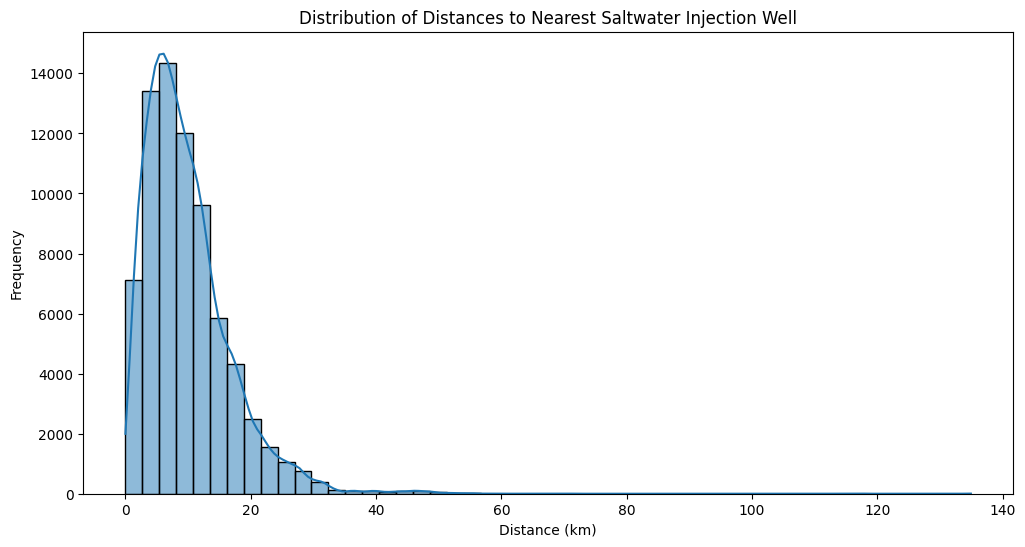

In [37]:
# Generate distribution plots for distances
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.histplot(nearest_swiw_df['Nearest_SWIW_km'], bins=50, kde=True)
plt.title('Distribution of Distances to Nearest Saltwater Injection Well')
plt.xlabel('Distance (km)')
plt.ylabel('Frequency')
plt.show()

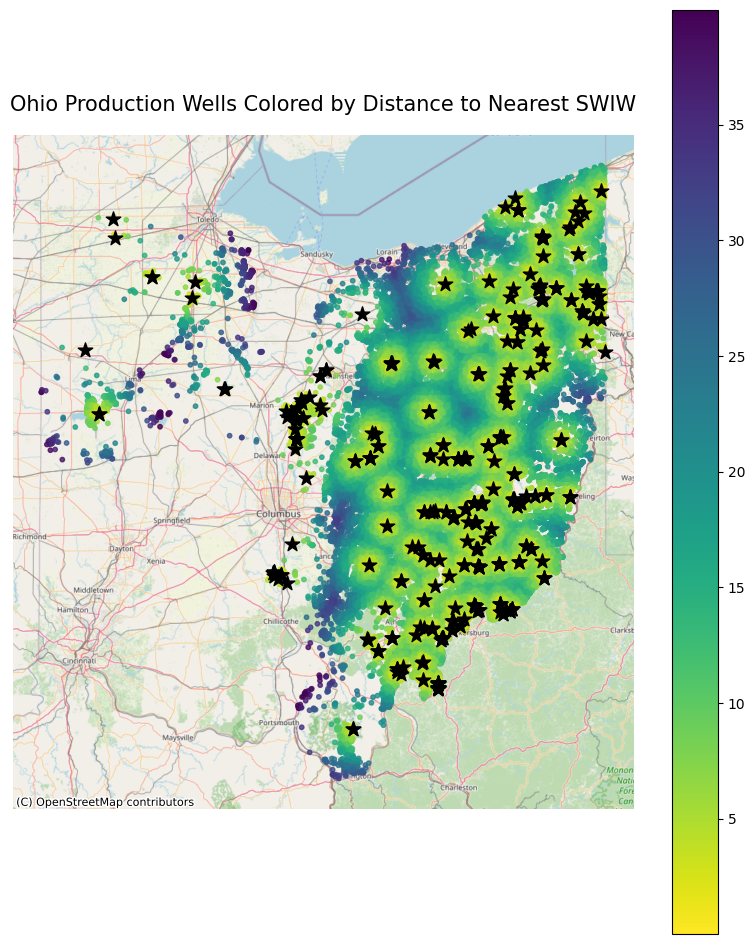

In [44]:
import contextily as ctx

really_nearest = nearest_swiw_df[nearest_swiw_df['Nearest_SWIW_km'] < 40]

prod_gdf = gpd.GeoDataFrame(
    really_nearest,
    geometry=gpd.points_from_xy(really_nearest["WELL LONGITUDE"], really_nearest["WELL LATITUDE"]),
    crs="EPSG:4326"
)

swiw_gdf = gpd.GeoDataFrame(
    swiw_df,
    geometry=gpd.points_from_xy(swiw_df["WH_LONG"], swiw_df["WH_LAT"]),
    crs="EPSG:4326"
)

prod_gdf = prod_gdf.to_crs(epsg=3857)
swiw_gdf = swiw_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 12))

prod_gdf.plot(
    ax=ax,
    column="Nearest_SWIW_km",
    cmap="viridis_r",
    markersize=10,
    alpha=0.8,
    legend=True
)

swiw_gdf.plot(
    ax=ax,
    color="black",
    marker="*",
    markersize=120,
    label="SWIW"
)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title("Ohio Production Wells Colored by Distance to Nearest SWIW", fontsize=15)
ax.set_axis_off()

plt.show()

In [52]:
# Basic Regression - Distance to Nearest Saltwater Injection Well vs. Well Production

import statsmodels.api as sm
distance_data = pd.read_csv('../data/distance/well_to_nearest_saltwater_updated.csv')
production_data = pd.read_csv('../data/final/annual_production_final.csv')
regression_data = pd.merge(distance_data, production_data, left_on='API WELL NUMBER', right_on='API Number')

regression_data = regression_data[(regression_data['Production Year'] == 2024) & (regression_data['Quarter (1, 2, 3, 4, n/a)'].isna()) & (regression_data['Gas (Mcf)'] > 0) & (regression_data['Gas (Mcf)'] < 10000)]

X = regression_data['Nearest_SWIW_km']
y = regression_data['Gas (Mcf)']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:              Gas (Mcf)   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                   0.07431
Date:                Sat, 15 Nov 2025   Prob (F-statistic):              0.785
Time:                        16:06:24   Log-Likelihood:            -1.8624e+05
No. Observations:               21827   AIC:                         3.725e+05
Df Residuals:                   21825   BIC:                         3.725e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             958.4516     15.501     

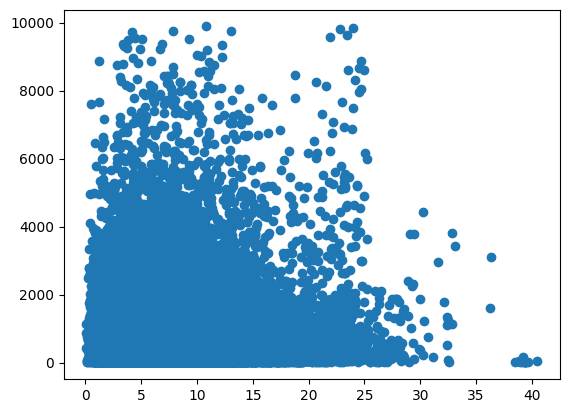

In [53]:
plt.scatter(regression_data['Nearest_SWIW_km'], regression_data['Gas (Mcf)'])

In [54]:
# Same thing for oil production
distance_data = pd.read_csv('../data/distance/well_to_nearest_saltwater_updated.csv')
production_data = pd.read_csv('../data/final/annual_production_final.csv')
regression_data = pd.merge(distance_data, production_data, left_on='API WELL NUMBER', right_on='API Number')

regression_data = regression_data[(regression_data['Production Year'] == 2024) & (regression_data['Quarter (1, 2, 3, 4, n/a)'].isna()) & (regression_data['Oil (Bbls)'] > 0)]

X = regression_data['Nearest_SWIW_km']
y = regression_data['Oil (Bbls)']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Oil (Bbls)   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     11.16
Date:                Sat, 15 Nov 2025   Prob (F-statistic):           0.000836
Time:                        16:06:40   Log-Likelihood:                -92979.
No. Observations:               13594   AIC:                         1.860e+05
Df Residuals:                   13592   BIC:                         1.860e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             111.0484      3.381     

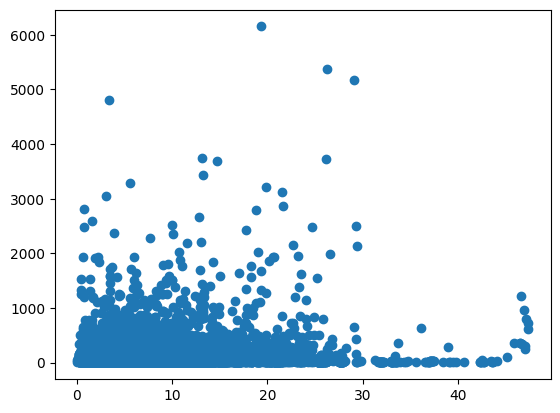

In [55]:
plt.scatter(regression_data['Nearest_SWIW_km'], regression_data['Oil (Bbls)'])

In [64]:
from datetime import datetime
import statsmodels.formula.api as smf

well_info = pd.read_csv("../data/final/well_information_final.csv")
dist_info = pd.read_csv("../data/distance/well_to_nearest_saltwater_updated.csv")
prod = pd.read_csv("../data/final/quarterly_production_final.csv")
permits = pd.read_csv("../data/final/permit_plug_list_final.csv")

swiw = permits[
    (permits['PROP_WLTYPE'] == 'SW_R') |
    (permits['APP_TYP_Description'] == 'Convert SWIW') |
    (permits['APP_TYP_Description'] == 'Salt Water Injection Well New Well')
].copy()
swiw = swiw[["API_WELLNO", "DT_APP_ISSUED", "WH_LAT", "WH_LONG"]]
swiw.rename(columns={"API_WELLNO": "API"}, inplace=True)
swiw["permit_date"] = pd.to_datetime(swiw["DT_APP_ISSUED"], errors="coerce")

dist_info.rename(columns={"API WELL NUMBER": "API"}, inplace=True)
prod.rename(columns={"API Number": "API"}, inplace=True)

prod = prod.merge(dist_info, on="API", how="left")

prod = prod.merge(
    swiw[["API", "permit_date"]].rename(columns={"API": "Nearest_SWIW_API"}),
    on="Nearest_SWIW_API", how="left"
)

# Take this out and switch to annual and quarterly if we want to consider both
prod = prod[prod['Quarter (1, 2, 3, 4, n/a)'].isin([1,2,3,4])]

def row_to_qdate(row):
    yr = row["Production Year"]
    q = row["Quarter (1, 2, 3, 4, n/a)"]
    if str(q).lower() in ["na", "n/a", None]:
        # annual → assign Q4
        return pd.Period(f"{yr}Q4").to_timestamp('Q')
    else:
        return pd.Period(f"{yr}Q{int(q)}").to_timestamp('Q')

prod["qdate"] = prod.apply(row_to_qdate, axis=1)

prod["rel_days"] = (prod["qdate"] - prod["permit_date"]).dt.days
prod["rel_quarters"] = (prod["rel_days"] / 90).round().astype("Int64")
prod = prod[~prod['rel_quarters'].isna()]
prod["post"] = (prod["rel_quarters"] >= 0).astype(int)

prod["inv_dist"] = 1 / (prod["Nearest_SWIW_km"] + 0.1)  # avoid div by zero
prod["log_inv_dist"] = np.log(prod["inv_dist"])

model = smf.ols(
    formula="""
        Q("Oil (Bbls)") ~ post * log_inv_dist
        + C(API) + C(qdate)
    """,
    data=prod
).fit(cov_type="cluster", cov_kwds={"groups": prod["API"]})

print(model.summary())

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:1896: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3466, but rank is 1
  warnings.warn('covariance of constraints does not have full '
c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


                            OLS Regression Results                            
Dep. Variable:        Q("Oil (Bbls)")   R-squared:                       0.456
Model:                            OLS   Adj. R-squared:                  0.445
Method:                 Least Squares   F-statistic:                -9.591e-06
Date:                Sat, 15 Nov 2025   Prob (F-statistic):               1.00
Time:                        16:38:38   Log-Likelihood:            -1.7885e+06
No. Observations:              177756   AIC:                         3.584e+06
Df Residuals:                  174290   BIC:                         3.619e+06
Df Model:                        3465                                         
Covariance Type:              cluster                                         
                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

In [ ]:
panel = prod[(prod["rel_quarters"] >= -12) & (prod["rel_quarters"] <= 12)].copy()
for k in range(-12, 13):
    panel[f"event_{k}"] = (panel["rel_quarters"] == k).astype(int)

event_cols = [f"event_{k}" for k in range(-12, 13) if k != -1]

formula = "Q('Oil (Bbls)') ~ " + " + ".join(event_cols) + " + C(API) + C(qdate)"

event_model = smf.ols(
    formula=formula,
    data=panel
).fit(cov_type="cluster", cov_kwds={"groups": panel["API"]})

In [ ]:
# Repeat for Gas

model = smf.ols(
    formula="""
        Q("Gas (Mcf)") ~ post * log_inv_dist
        + C(API) + C(qdate)
    """,
    data=prod
).fit(cov_type="cluster", cov_kwds={"groups": prod["API"]})

print(model.summary())

In [71]:
import pandas as pd
import numpy as np
from pygam import LinearGAM, s, f
from dateutil.relativedelta import relativedelta

wellinfo = pd.read_csv("../data/final/well_information_final.csv")
distance = pd.read_csv("../data/distance/well_to_nearest_saltwater_updated.csv")
prod = pd.read_csv("../data/final/quarterly_production_final.csv")
perm = pd.read_csv("../data/final/permit_plug_list_final.csv")

prod['QUARTER'] = prod['Quarter (1, 2, 3, 4, n/a)']

# Standardize column names
distance.columns = [c.strip().upper().replace(" ", "_") for c in distance.columns]
prod.columns = [c.strip().upper().replace(" ", "_") for c in prod.columns]
wellinfo.columns = [c.strip().upper().replace(" ", "_") for c in wellinfo.columns]
perm.columns = [c.strip().upper().replace(" ", "_") for c in perm.columns]

swiw = perm[
    (perm['PROP_WLTYPE'] == 'SW_R') |
    (perm['APP_TYP_DESCRIPTION'] == 'Convert SWIW') |
    (perm['APP_TYP_DESCRIPTION'] == 'Salt Water Injection Well New Well')
].copy()

# Extract SWIW activation date
swiw["DT_APP_ISSUED"] = pd.to_datetime(swiw["DT_APP_ISSUED"], errors="coerce")
swiw = swiw[["API_WELLNO", "DT_APP_ISSUED"]]
swiw = swiw.groupby("API_WELLNO", as_index=False).min()

distance = distance.rename(columns={"API_WELL_NUMBER": "API"})
swiw = swiw.rename(columns={"API_WELLNO": "SWIW_API"})

distance = distance.rename(columns={"NEAREST_SWIW_API": "SWIW_API"})

dist_merge = distance.merge(swiw, on="SWIW_API", how="left")
dist_merge = dist_merge.rename(columns={"DT_APP_ISSUED": "NEAREST_SWIW_DATE"})

prod["QUARTER"] = prod["QUARTER"].replace("n/a", np.nan)
prod["PRODUCTION_YEAR"] = prod["PRODUCTION_YEAR"].astype(int)

prod = prod[prod['QUARTER'].isin([1,2,3,4])]

def make_date(row):
    if pd.isna(row["QUARTER"]):
        return pd.to_datetime(f"{int(row['PRODUCTION_YEAR'])}-07-01")
    else:
        q = int(row["QUARTER"])
        month = {1:1, 2:4, 3:7, 4:10}[q]
        return pd.to_datetime(f"{int(row['PRODUCTION_YEAR'])}-{month}-01")

prod["DATE"] = prod.apply(make_date, axis=1)

prod = prod.rename(columns={"API_NUMBER": "API"})

df = (
    prod.merge(dist_merge, on="API", how="left")
)

df["NEAREST_SWIW_DATE"] = pd.to_datetime(df["NEAREST_SWIW_DATE"], errors="coerce")
df["DATE"] = pd.to_datetime(df["DATE"])

df["SWIW_ACTIVE"] = (df["DATE"] >= df["NEAREST_SWIW_DATE"]).astype(int)

df = df.sort_values("DATE")
df["T_INDEX"] = df["DATE"].rank(method="dense")

df = df.dropna(subset=["NEAREST_SWIW_KM", "OIL_(BBLS)", "T_INDEX"])

df["OIL"] = df["OIL_(BBLS)"]

# Encode categorical variables
df["API_CAT"] = df["API"].astype("category").cat.codes
df["FORMATION_CAT"] = df["PRODUCING_FORMATION"].astype("category").cat.codes
df["COUNTY_CAT"] = df["COUNTY"].astype("category").cat.codes
df["TREAT_TIME"] = df["T_INDEX"] * df["SWIW_ACTIVE"]

# Final model matrix
X = df[[
    "T_INDEX",
    "NEAREST_SWIW_KM",
    "TREAT_TIME",
    "FORMATION_CAT",
    "COUNTY_CAT"
]].values

y = df["OIL"].values

print("Fitting GAM... (this may take a few minutes)")

gam = LinearGAM(
    s(0)               # baseline time smooth
    + s(1)             # smooth distance effect
    + s(2)             # smooth treatment effect: time × SWIW_ACTIVE
    + f(3)    # formation random effect
    + f(4)    # county random effect
).fit(X, y)

print("Done!")

print("\nGAM model summary:")
print(gam.summary())


Fitting GAM... (this may take a few minutes)
Done!

GAM model summary:
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     62.9309
Link Function:                     IdentityLink Log Likelihood:                              -1985968.4202
Number of Samples:                       106052 AIC:                                          3972064.7022
                                                AICc:                                         3972064.7805
                                                GCV:                                          54216437.832
                                                Scale:                                       54158531.5524
                                                Pseudo R-Squared:        

C:\Users\willf\AppData\Local\Temp\ipykernel_12536\3663801347.py:101: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


Residualized OIL after removing well, formation, and county effects
GAM fitted on residuals
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     42.0071
Link Function:                     IdentityLink Log Likelihood:                              -1938804.6779
Number of Samples:                       106052 AIC:                                          3877695.3698
                                                AICc:                                         3877695.4055
                                                GCV:                                         34740491.7899
                                                Scale:                                       34715723.4714
                                                Pseu

C:\Users\willf\AppData\Local\Temp\ipykernel_12536\1559681277.py:41: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


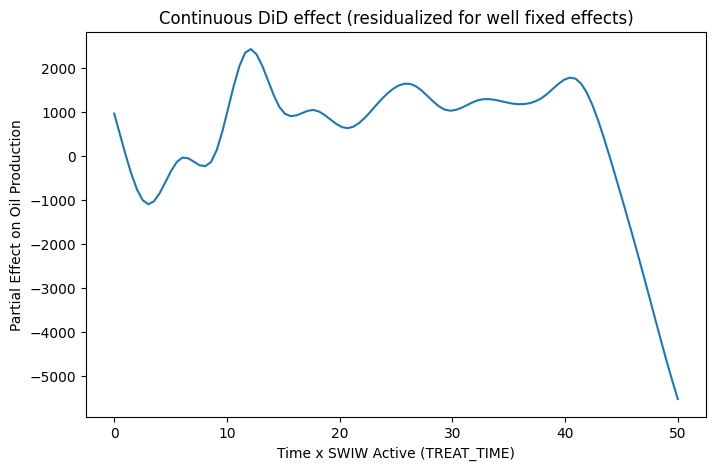

In [72]:
import pandas as pd
import numpy as np
from pygam import LinearGAM, s, f
import statsmodels.api as sm

# -------------------------
# Step 1: Residualize out well fixed effects
# -------------------------

# API dummies
api_dummies = pd.get_dummies(df['API'], drop_first=True)

# Optionally include formation/county as controls
formation_dummies = pd.get_dummies(df['FORMATION_CAT'], drop_first=True)
county_dummies = pd.get_dummies(df['COUNTY_CAT'], drop_first=True)

# Combine
X_fe = pd.concat([api_dummies, formation_dummies, county_dummies], axis=1)
y = df['OIL']

# Fit linear model to remove well-level (API) effects
fe_model = sm.OLS(y, X_fe).fit()
df['OIL_resid'] = fe_model.resid

print("Residualized OIL after removing well, formation, and county effects")

# -------------------------
# Step 2: Fit GAM on residuals
# -------------------------

X_gam = df[["T_INDEX", "NEAREST_SWIW_KM", "TREAT_TIME"]].values
y_gam = df["OIL_resid"].values

gam = LinearGAM(
    s(0) +  # smooth time trend
    s(1) +  # smooth distance
    s(2)    # continuous DiD effect
).fit(X_gam, y_gam)

print("GAM fitted on residuals")
print(gam.summary())

# -------------------------
# Step 3: Plot continuous DiD effect
# -------------------------
import matplotlib.pyplot as plt

XX = gam.generate_X_grid(term=2)
plt.figure(figsize=(8,5))
plt.plot(XX[:,2], gam.partial_dependence(term=2, X=XX))
plt.xlabel("Time x SWIW Active (TREAT_TIME)")
plt.ylabel("Partial Effect on Oil Production")
plt.title("Continuous DiD effect (residualized for well fixed effects)")
plt.show()
